In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
PathLengthToCurrent = {5:None, 7:None, 9:None, 11:None, 13:None, 15:None}
CrossbarSizeToCurrent = {'32':None, '64':None, '128':None, '256':None, '512':None, '1024':None}
NeighboringLrsToCurrent = {0:None, 2:None, 4:None, 6:None, 8:None, 10:None}

In [8]:
import random

def find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex):

    wordLineInputs = [0]
    # Custom function to emulate an ordered set using a list
    def add_to_ordered_set(ordered_set, element):
        if element not in ordered_set:
            ordered_set.append(element)

    # R_Off = self.R_Off  # Very large (transistor off)
    # R_HRS = self.R_HRS_Map[design_ID]  # High-resistance state of the memory cell
    # R_LRS = self.R_LRS  # Low-resistance state

    R_Off = 1e12
    R_HRS = 1e6
    R_LRS = 200
    
    R_Line_Out = 200  # 200 ohms from each column node to GND
    R_Not = 1e12  # Large resistance for non-output columns
    R_source   = 100  # Series resistor from 0.2 V source to row 0
    
    # Voltage source for the first row (0.2V)
    Vsrc = 0.2  

    # for row in Crossbar:
    #     print(row)



    Resistance_matrix = np.where(Crossbar == 0, R_HRS, 
                                np.where(Crossbar == 1, R_LRS, 
                                         np.where(Crossbar == 2, R_Off, Crossbar)))
    
    # Resistance_matrix = np.where(Crossbar_design == 1,
    #                        self.R_LRS,          # low-resistance state
    #                        self.R_HRS_Map[design_ID])          # high-resistance state

    # -----------------------------
    # 2) Prepare the crossbar data
    # -----------------------------
    crossbar_size = Resistance_matrix.shape[0]

    # -----------------------------
    # 3) Construct the KCL system
    #    We have #rows + #columns unknowns:
    #       Vr0, Vr1, ..., Vr(N-1), Vc0, Vc1, ..., Vc(N-1)
    # -----------------------------
    num_vars = 2 * crossbar_size  
    A = np.zeros((num_vars, num_vars))  # Coefficient matrix
    b = np.zeros(num_vars)  # Constant vector

    # -----------------------------
    # 3a) Row equations (KCL at each row node)
    # -----------------------------
    for i in range(crossbar_size):
        if i in wordLineInputs:
            #
            # For row 0, we have an incoming/outgoing current through R_source to the 0.2V supply.
            # The KCL for row 0 is:
            #   Σ_j (Vr0 - Vc_j)/R(i,j) + (Vr0 - 0.2)/R_source = 0
            #
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # +1/Rij for Vr[i]
                A[i, crossbar_size + j] -= 1.0 / Rij    # -1/Rij for Vc[j]

            # Now add the series resistor with the source (0.2 V):
            A[i, i] += 1.0 / R_source  # Coefficient for Vr0
            
            # Move the known source voltage part to the RHS
            b[i] = (Vsrc / R_source)

        else:
            # For row i (i > 0), normal crossbar KCL with no direct voltage source:
            #   Σ_j (Vri - Vcj)/R(i,j) = 0
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # Coefficient for Vr_i
                A[i, crossbar_size + j] -= 1.0 / Rij   # Coefficient for Vc_j
            # b[i] remains 0

    # -----------------------------
    # 3b) Column equations (KCL at each column node)
    #       If the column is in output_bitlines => goes to GND through R_Line_Out
    #       Otherwise => goes to GND through R_Not
    # -----------------------------
    # print('output_bitlines',output_bitlines)
    for j in range(crossbar_size):
        if j == outputBitlineIndex:
            R_ground = R_Line_Out  # If it's an output bitline, connects to ground through R_Line_Out
        else:
            R_ground = R_Not  # If not an output bitline, connect to ground through R_Not

        # The KCL for column j is:
        #    Vc_j / R_ground + Σ_i (Vc_j - Vr_i)/R(i,j) = 0
        #
        # Expand:
        #    (Vc_j / R_ground) + Σ_i (Vc_j / R(i,j) - Vr_i / R(i,j)) = 0
        # => (1/R_ground + Σ_i (1/R(i,j))) * Vc_j  - Σ_i(1/R(i,j)) * Vr_i = 0
        
        A[crossbar_size + j, crossbar_size + j] = 1 / R_ground  # Self term
        for i in range(crossbar_size):
            Rij = Resistance_matrix[i][j]
            A[crossbar_size + j, crossbar_size + j] += 1 / Rij  # Self term
            A[crossbar_size + j, i] -= 1 / Rij  # Interaction with row

    # -----------------------------
    # 4) Solve the system A x = b
    #    where x = [Vr_0, ..., Vr_(N-1), Vc_0, ..., Vc_(N-1)]
    # -----------------------------
    solution = np.linalg.solve(A, b)

    # Extract row voltages Vr and column voltages Vc
    Vr = solution[:crossbar_size]*1000  # Row voltages
    Vc = solution[crossbar_size:]*1000  # Column voltages

    # Compute currents through each resistor
    currentInDevices = (Vr[:, None] - Vc[None, :]) / Resistance_matrix

    # -----------------------------
    # 5) Compute output currents
    #    The current from each output column j is simply
    #    I_out(j) = Vc_j / R_Line_Out (if j is an output bitline)
    # -----------------------------
    CurrentOutput = Vc[outputBitlineIndex] / R_Line_Out
    
    return CurrentOutput

def GeneratePath(size):
    path = [
    (0, 6),  #1
    (5, 6),  #2
    (5, 2),  #3
    (23, 2),  #4
    (23, 19),  #5
    (12, 19),  #6
    (12, 27),  #7
    (25, 27),  #8
    (25, 14),  #9
    (16, 14),  #10
    (16, 24),  #11
    (13, 24),  #12
    (13, 25),  #13
    (14, 25),  #14
    (14, 28),  #15
    ]
    return [path[i] for i in range(size)]

oneCurrents_pathbreak = []
zeroCurrents_pathbreak = []

oneCurrents_pathlength = []
zeroCurrents_pathlength = []

oneCurrents_crossbar = []
zeroCurrents_crossbar = []

path = GeneratePath(size=11)
    
Crossbar = np.zeros((64, 64))
for x,y in path:
    Crossbar[x][y]=1

outputBitlineIndex = path[-1][1]  #output

oneCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)

# print('oneCurrent', oneCurrent, outputBitlineIndex)

PathBreaks = [0,1,2,3,4,5,6,7,8,9]
for PathBreak in PathBreaks:
    
    oneCurrents_pathbreak.append(oneCurrent)

    Crossbar = np.zeros((64, 64))
    path = GeneratePath(size=11)
    path.pop(PathBreak)
    for x,y in path:
        Crossbar[x][y]=1

    
    outputBitlineIndex = path[-1][1]  #output
    
    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    zeroCurrents_pathbreak.append(zeroCurrent)

PathLengths = [3, 5, 7, 9, 11, 13, 15]
for length in PathLengths:
    path = GeneratePath(size=length)
    
    Crossbar = np.zeros((64, 64))
    for x,y in path:
        Crossbar[x][y]=1
    outputBitlineIndex = path[-1][1]  #output

    oneCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    oneCurrents_pathlength.append(oneCurrent)

    path = GeneratePath(size=length)
    path.pop(length//2)
    
    Crossbar = np.zeros((64, 64))
    for x,y in path:
        Crossbar[x][y]=1
    outputBitlineIndex = path[-1][1]  #output

    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    zeroCurrents_pathlength.append(zeroCurrent)

    
    
Crossbarsizes = [32, 64, 128, 256, 512, 1024]
for size in Crossbarsizes:

    path = GeneratePath(size=11)
    Crossbar = np.zeros((size, size))
    for x,y in path:
        Crossbar[x][y]=1
    
    outputBitlineIndex = path[-1][1]  #output
    
    oneCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    
    oneCurrents_crossbar.append(oneCurrent)

    Crossbar = np.zeros((size, size))
    path = GeneratePath(size=11)
    path.pop(5)
    for x,y in path:
        Crossbar[x][y]=1

    
    outputBitlineIndex = path[-1][1]  #output
    
    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    zeroCurrents_crossbar.append(zeroCurrent)

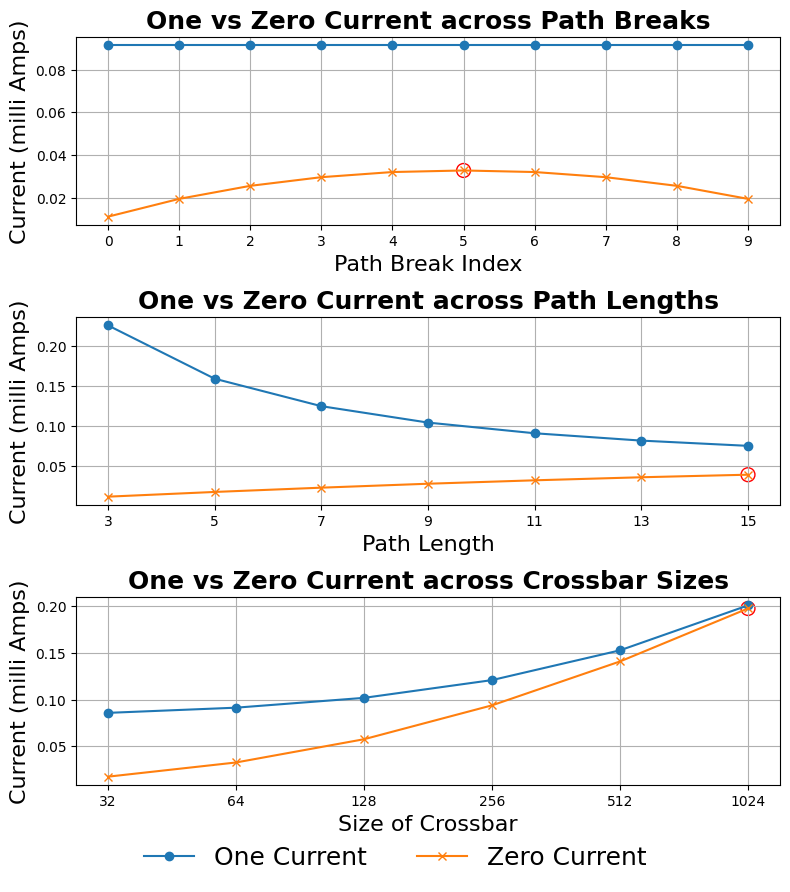

In [20]:
import numpy as np

# Recreate required arrays with dummy test values to simulate the original logic.
# You can replace these with actual stored values or load them from files if needed.
# zeroCurrents_pathbreak = [0.02, 0.03, 0.015, 0.01, 0.05, 0.07, 0.02, 0.06, 0.03, 0.01]
# oneCurrents_pathbreak = [0.15] * 10

# zeroCurrents_pathlength = [0.01, 0.02, 0.04, 0.05, 0.06, 0.03, 0.02]
# oneCurrents_pathlength = [0.18] * 7

# zeroCurrents_crossbar = [0.01, 0.03, 0.04, 0.06, 0.07, 0.09]
# oneCurrents_crossbar = [0.2] * 6

# Re-run the plotting code with the dummy data
# PathBreaks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
PathBreaks_str = [str(pathBreak) for pathBreak in PathBreaks]

# PathLengths = [3, 5, 7, 9, 11, 13, 15]
PathLengths_str = [str(length) for length in PathLengths]

# Crossbarsizes = [32, 64, 128, 256, 512, 1024]
Crossbarsizes_str = [str(size) for size in Crossbarsizes]

# Identify max points
max_zero_current_path = max(zeroCurrents_pathbreak)
max_index_path = zeroCurrents_pathbreak.index(max_zero_current_path)
max_path_break = PathBreaks_str[max_index_path]

max_zero_current_crossbar = max(zeroCurrents_crossbar)
max_index_crossbar = zeroCurrents_crossbar.index(max_zero_current_crossbar)

max_zero_current_pathlength = max(zeroCurrents_pathlength)
max_index_pathlength = zeroCurrents_pathlength.index(max_zero_current_pathlength)
max_pathlength = PathLengths_str[max_index_pathlength]

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharey=False)

# Plot 1
axs[0].plot(PathBreaks_str, oneCurrents_pathbreak, marker='o', label='One Current')
axs[0].plot(PathBreaks_str, zeroCurrents_pathbreak, marker='x', label='Zero Current')
axs[0].scatter([max_path_break], [max_zero_current_path], color='red', s=100, facecolors='none', edgecolors='red')
axs[0].set_xlabel('Path Break Index', fontsize=16)
axs[0].set_ylabel('Current (milli Amps)', fontsize=16)
axs[0].set_title('One vs Zero Current across Path Breaks', fontsize=18, fontweight='bold')
axs[0].grid(True)

# Plot 2
axs[1].plot(PathLengths_str, oneCurrents_pathlength, marker='o', label='One Current')
axs[1].plot(PathLengths_str, zeroCurrents_pathlength, marker='x', label='Zero Current')
axs[1].scatter([max_pathlength], [max_zero_current_pathlength], color='red', s=100, facecolors='none', edgecolors='red')
axs[1].set_xlabel('Path Length', fontsize=16)
axs[1].set_ylabel('Current (milli Amps)', fontsize=16)
axs[1].set_title('One vs Zero Current across Path Lengths', fontsize=18, fontweight='bold')
axs[1].grid(True)

# Plot 3
axs[2].plot(Crossbarsizes_str, oneCurrents_crossbar, marker='o', label='One Current')
axs[2].plot(Crossbarsizes_str, zeroCurrents_crossbar, marker='x', label='Zero Current')
axs[2].scatter([Crossbarsizes_str[max_index_crossbar]], [max_zero_current_crossbar], color='red', s=100, facecolors='none', edgecolors='red')
axs[2].set_xlabel('Size of Crossbar', fontsize=16)
axs[2].set_ylabel('Current (milli Amps)', fontsize=16)
axs[2].set_title('One vs Zero Current across Crossbar Sizes', fontsize=18, fontweight='bold')
axs[2].grid(True)

# Shared legend at bottom
handles, labels = axs[2].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=18, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space at bottom for legend
plt.savefig("C:/Users/nithi/jupyter-files/Path/Circuit Analysis/pathBreak.png", dpi=300)
plt.show()

<h1>Multiple wordline inputs</h1>

In [117]:
import random

def find_path_current_execution_in_crossbar(Crossbar, wordLineInputs, outputBitlineIndex):

    # Custom function to emulate an ordered set using a list
    def add_to_ordered_set(ordered_set, element):
        if element not in ordered_set:
            ordered_set.append(element)

    # R_Off = self.R_Off  # Very large (transistor off)
    # R_HRS = self.R_HRS_Map[design_ID]  # High-resistance state of the memory cell
    # R_LRS = self.R_LRS  # Low-resistance state

    R_Off = 1e12
    R_HRS = 1e6
    R_LRS = 200
    
    R_Line_Out = 200  # 200 ohms from each column node to GND
    R_Not = 1e12  # Large resistance for non-output columns
    R_source   = 100  # Series resistor from 0.2 V source to row 0
    
    # Voltage source for the first row (0.2V)
    Vsrc = 0.2  

    # for row in Crossbar:
    #     print(row)



    Resistance_matrix = np.where(Crossbar == 0, R_HRS, 
                                np.where(Crossbar == 1, R_LRS, 
                                         np.where(Crossbar == 2, R_Off, Crossbar)))
    
    # Resistance_matrix = np.where(Crossbar_design == 1,
    #                        self.R_LRS,          # low-resistance state
    #                        self.R_HRS_Map[design_ID])          # high-resistance state

    # -----------------------------
    # 2) Prepare the crossbar data
    # -----------------------------
    crossbar_size = Resistance_matrix.shape[0]

    # -----------------------------
    # 3) Construct the KCL system
    #    We have #rows + #columns unknowns:
    #       Vr0, Vr1, ..., Vr(N-1), Vc0, Vc1, ..., Vc(N-1)
    # -----------------------------
    num_vars = 2 * crossbar_size  
    A = np.zeros((num_vars, num_vars))  # Coefficient matrix
    b = np.zeros(num_vars)  # Constant vector

    # -----------------------------
    # 3a) Row equations (KCL at each row node)
    # -----------------------------
    for i in range(crossbar_size):
        if i in wordLineInputs:
            #
            # For row 0, we have an incoming/outgoing current through R_source to the 0.2V supply.
            # The KCL for row 0 is:
            #   Σ_j (Vr0 - Vc_j)/R(i,j) + (Vr0 - 0.2)/R_source = 0
            #
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # +1/Rij for Vr[i]
                A[i, crossbar_size + j] -= 1.0 / Rij    # -1/Rij for Vc[j]

            # Now add the series resistor with the source (0.2 V):
            A[i, i] += 1.0 / R_source  # Coefficient for Vr0
            
            # Move the known source voltage part to the RHS
            b[i] = (Vsrc / R_source)

        else:
            # For row i (i > 0), normal crossbar KCL with no direct voltage source:
            #   Σ_j (Vri - Vcj)/R(i,j) = 0
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # Coefficient for Vr_i
                A[i, crossbar_size + j] -= 1.0 / Rij   # Coefficient for Vc_j
            # b[i] remains 0

    # -----------------------------
    # 3b) Column equations (KCL at each column node)
    #       If the column is in output_bitlines => goes to GND through R_Line_Out
    #       Otherwise => goes to GND through R_Not
    # -----------------------------
    # print('output_bitlines',output_bitlines)
    for j in range(crossbar_size):
        if j == outputBitlineIndex:
            R_ground = R_Line_Out  # If it's an output bitline, connects to ground through R_Line_Out
        else:
            R_ground = R_Not  # If not an output bitline, connect to ground through R_Not

        # The KCL for column j is:
        #    Vc_j / R_ground + Σ_i (Vc_j - Vr_i)/R(i,j) = 0
        #
        # Expand:
        #    (Vc_j / R_ground) + Σ_i (Vc_j / R(i,j) - Vr_i / R(i,j)) = 0
        # => (1/R_ground + Σ_i (1/R(i,j))) * Vc_j  - Σ_i(1/R(i,j)) * Vr_i = 0
        
        A[crossbar_size + j, crossbar_size + j] = 1 / R_ground  # Self term
        for i in range(crossbar_size):
            Rij = Resistance_matrix[i][j]
            A[crossbar_size + j, crossbar_size + j] += 1 / Rij  # Self term
            A[crossbar_size + j, i] -= 1 / Rij  # Interaction with row

    # -----------------------------
    # 4) Solve the system A x = b
    #    where x = [Vr_0, ..., Vr_(N-1), Vc_0, ..., Vc_(N-1)]
    # -----------------------------
    solution = np.linalg.solve(A, b)

    # Extract row voltages Vr and column voltages Vc
    Vr = solution[:crossbar_size]*1000  # Row voltages
    Vc = solution[crossbar_size:]*1000  # Column voltages

    # Compute currents through each resistor
    currentInDevices = (Vr[:, None] - Vc[None, :]) / Resistance_matrix

    # -----------------------------
    # 5) Compute output currents
    #    The current from each output column j is simply
    #    I_out(j) = Vc_j / R_Line_Out (if j is an output bitline)
    # -----------------------------
    CurrentOutput = Vc[outputBitlineIndex] / R_Line_Out
    
    return CurrentOutput

path_global = [
    (0, 1),  #1
    (1, 2),  #2
    (2, 3),  #3
    (3, 1),  #4
    (3, 2),  #5
    (4, 2),  #6
    (4, 3),  #7
    (5, 3),  #8
        ]

oneCurrents = []
zeroCurrents = []

path = [cell for cell in path_global]
wordlineinput = [0, 1, 2, 3, 4]
outputBitlineIndex = path[-1][1]  #output

Crossbar = np.zeros((64, 64))
for x,y in path:
    Crossbar[x][y]=1
    
oneCurrent = find_path_current_execution_in_crossbar(Crossbar, wordlineinput, outputBitlineIndex)

print('oneCurrent', oneCurrent, outputBitlineIndex)


path_global = [
    (0, 0),  #0
    (1, 1),  #1
    (2, 2),  #2
    (3, 3),  #3
    (4, 4),  #4
    
    (5, 0),  #5
    (5, 1),  #6
    (6, 1),  #7
    (6, 2),  #8
    (7, 2),  #9
    (7, 3),  #11
    (8, 3),  #12
    (8, 4),  #13
    (9, 4),  #14
    (9, 5),  #15
        ]

PathBreaks = [
                [9], #final node
                [9,8],  #final + 1
                [9,8,7],  #final + 1
                [9,8,7,6],  #final + 1
                [9,8,7,6,5],  #final + 1
    
                [5],  #final + 1
                [6],  #final + 1
                [7],  #final + 1
                [8],  #final + 1
                [9],  #final + 1
                # [6],  #final
            ]
oneCurrents = [oneCurrent]*len(PathBreaks)

for i, PathBreak_cells in enumerate(PathBreaks):

    path = [cell for j,cell in enumerate(path_global) if j not in PathBreak_cells]
    wordlineinput = [0, 1, 2, 3, 4]
    if(i==5):
        wordlineinput = [0]
    elif(i==6):
        wordlineinput = [1]
    elif(i==7):
        wordlineinput = [2]
    elif(i==8):
        wordlineinput = [3]
    elif(i==9):
        wordlineinput = [4]
        
    outputBitlineIndex = 5  #output

    Crossbar = np.zeros((64, 64))
    for x,y in path:
        Crossbar[x][y]=1
    
    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, wordlineinput, outputBitlineIndex)
    zeroCurrents.append(zeroCurrent)

    if(i>2):
        print()
    print('zeroCurrent', zeroCurrent, outputBitlineIndex, PathBreak)

oneCurrent 0.5839803457921979 3
zeroCurrent 0.2556359235159507 5 1
zeroCurrent 0.2556316502251717 5 1
zeroCurrent 0.2554217750368698 5 1

zeroCurrent 0.25541826556375963 5 1

zeroCurrent 0.2551778349842852 5 1

zeroCurrent 0.02034043142701899 5 1

zeroCurrent 0.10542139657208965 5 1

zeroCurrent 0.12633666451144582 5 1

zeroCurrent 0.16055756567785423 5 1

zeroCurrent 0.2256397612085273 5 1
